# Text Analytics — Sentiment Classification on IMDB Movie Reviews

**Objective:** classify 25,000 IMDB movie reviews as *positive* or *negative*.

**Pipeline:** Data Loading → Cleaning & Normalisation → EDA → Feature Extraction → Modeling → Evaluation → Conclusion.

The text is cleaned (HTML/URL/punctuation removal, stopword removal, POS-aware lemmatisation), converted to
numeric features with Bag-of-Words and TF-IDF, and then classified with Multinomial Naive Bayes, Logistic
Regression and a Linear SVM. Models are compared on accuracy, precision, recall and F1.

## 1. Setup and Imports

All libraries are imported up front so the notebook is reproducible end-to-end. The NLTK resources are
downloaded once: `stopwords` for filtering, `wordnet`/`omw-1.4` for lemmatisation, `punkt` for
`word_tokenize`, and `averaged_perceptron_tagger` for the POS tagging added in the lemmatisation step.

In [ ]:
# importing all the necessary libraries
import re
import pandas as pd
import numpy as np
import nltk

In [ ]:
# NLTK resources used throughout the notebook (safe to re-run; already-present data is skipped)
for resource in ['stopwords', 'wordnet', 'omw-1.4', 'punkt', 'punkt_tab',
                 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng']:
    nltk.download(resource, quiet=True)

print('NLTK resources ready.')

NLTK resources ready.


## 2. Data Loading

The dataset has two columns: `review` (free text) and `sentiment` (`positive` / `negative`).
The path falls back to the local filename so the notebook runs both on Colab and locally.

In [ ]:
import os

DATA_PATH = '/content/IMDB_25000_rephrased.csv'
if not os.path.exists(DATA_PATH):                 # fallback when not running on Colab
    DATA_PATH = 'IMDB_25000_rephrased.csv'

df = pd.read_csv(DATA_PATH, engine='python')
df.head()

,review,sentiment
0,humorous. Sad. Charming. These are all words t...,positive
1,Let me start of by saying that I never wanted ...,negative
2,"""The Kennel Murder Case"" starts off at a run a...",positive
3,"Forget Plan 9, this is the ultimate fiasco, a ...",negative
4,It seems whenever a mainstream film company wa...,negative


In [ ]:
df['review'][3]

'Forget Plan 9, this is the ultimate fiasco, a costume drama, ineptly was directed, scripted, acted, etc. This film is based on Isabel Allende\'s not-so-much-better novel. I strongly dislike Meryl Streep and Antonio Banderas (in non-Spanish films), and the other performers, including Winona, my favourite female performer and Jeremy Irons try hard to get over such a awful script. Plenty of mistakes (like, for example, since when does it snow in Xmas in Chile?) and very cruel, with tons of that evil named "magic realism", this stands out as the worst film of all time. It totally sucks!!!'

In [ ]:
df.describe()

,review,sentiment
count,25000,25000
unique,24892,2
top,"Hilarious, clean, light-hearted, and quote-wor...",positive
freq,3,12500


`describe()` on an object column reports `count`, `unique`, `top` and `freq`. The gap between **count (25000)**
and **unique** is the number of duplicated reviews — dealt with in the next section.

## 3. Duplicate Reviews

**Why this matters.** Duplicates cause two specific problems in a classification project:

1. **Leakage across the split.** If the same review lands in both train and test, the test score measures
   memorisation rather than generalisation, and the reported accuracy is optimistically biased.
2. **Implicit re-weighting.** A duplicated review counts twice in the vocabulary statistics, so its
   vocabulary is slightly over-weighted in both Bag-of-Words counts and IDF.

The count is small relative to the corpus, so removing them costs almost nothing in training signal while
eliminating the leakage risk entirely.

In [ ]:
# How many exact duplicate reviews are there, and are they consistently labelled?
dup_rows   = df.duplicated(subset=['review'], keep=False)
dup_exact  = df.duplicated(keep='first').sum()          # identical review AND sentiment
dup_review = df['review'].duplicated(keep='first').sum() # identical review text only

print(f'Rows with a duplicated review text : {dup_rows.sum()}')
print(f'Duplicate review+sentiment pairs   : {dup_exact}')
print(f'Duplicate review texts             : {dup_review}')

# Are any duplicated texts labelled inconsistently (same review, both sentiments)?
conflicting = (df[dup_rows].groupby('review')['sentiment'].nunique() > 1).sum()
print(f'Duplicated texts with conflicting labels: {conflicting}')

df[dup_rows].sort_values('review').head(4)

Rows with a duplicated review text : 215
Duplicate review+sentiment pairs   : 108
Duplicate review texts             : 108
Duplicated texts with conflicting labels: 0


,review,sentiment
12185,(Spoilers)<br /><br />Oh sure it's based on Mo...,negative
22734,(Spoilers)<br /><br />Oh sure it's based on Mo...,negative
2106,(This is a review of the later English release...,negative
14570,(This is a review of the later English release...,negative


In [ ]:
# Decision: drop duplicates, keeping the first occurrence.
before = df.shape[0]
df = df.drop_duplicates(subset=['review'], keep='first').reset_index(drop=True)
after = df.shape[0]

print(f'Rows before : {before}')
print(f'Rows removed: {before - after}')
print(f'Rows after  : {after}')
print()
print('Class balance after de-duplication:')
print(df['sentiment'].value_counts())

Rows before : 25000
Rows removed: 108
Rows after  : 24892

Class balance after de-duplication:
sentiment
positive    12466
negative    12426
Name: count, dtype: int64


**Decision: dropped.** The duplicates are a small fraction of the corpus and removing them eliminates
train/test leakage. The class balance is essentially unchanged afterwards, so de-duplication has not
introduced any skew that the models would have to compensate for.

## 4. Data Preprocessing

Remove HTML tags, URLs, non-alphanumeric characters & convert to lowercase.

IMDB reviews are scraped web text, so they carry `<br />` tags and the occasional URL. Left in place, these
become high-frequency tokens that carry no sentiment signal at all — `br` would end up as one of the most
common "words" in the corpus.

In [ ]:
# Keep a copy of the raw text so cleaning can be evaluated before/after in the EDA section
df['review_raw'] = df['review'].copy()
print('Raw text preserved in df[\'review_raw\'] for the before/after length comparison.')

Raw text preserved in df['review_raw'] for the before/after length comparison.


In [ ]:
def remove_tags(string):

    removelist = ""  # Add any characters you'd like to keep

    # Remove HTML tags
    result = re.sub(r'<[^>]+>', '', string)

    # Remove URLs
    result = re.sub(r'https?://\S+', '', result)

    # Expand contracted negations BEFORE stripping punctuation, so "didn't" -> "did not"
    # instead of collapsing into meaningless fragments like "didn" + "t"
    result = re.sub(r"n't\b", " not", result)

    # Remove non-alphanumeric characters (except for those in the removelist)
    result = re.sub(r'[^a-zA-Z0-9' + removelist + r'\s]', ' ', result)

    # Convert to lowercase
    result = result.lower()

    return result

In [ ]:
# Suppose we have a text Which Contains HTML Tags, URLs, non-alphanumeric characters

string = "<html><body><p> Movie 1</p><p> Actor - Aamir Khan</p><p> Click here to <a href='http://google.com'>download</a></p></body></html>"

print(remove_tags(string))

 movie 1 actor   aamir khan click here to download


In [ ]:
# Text With Punctuation.

string2 = "The quick brown fox jumps over the lazy dog. However, the dog doesn't seem impressed! Oh no, it just yawned. How disappointing! Maybe a squirrel would elicit a reaction. Alas, the fox is out of luck."

# Remove Punctuation.

print(remove_tags(string2))

the quick brown fox jumps over the lazy dog  however  the dog doesn t seem impressed  oh no  it just yawned  how disappointing  maybe a squirrel would elicit a reaction  alas  the fox is out of luck 


In [ ]:
# Apply Function to Remove HTML Tags in our Dataset Colum Review.

df['review'] = df['review'].apply(remove_tags)

### 4.1 Stopword Removal

Stopwords (*the*, *is*, *and* …) appear in almost every document, so they inflate the feature space without
helping to separate the classes.

**Note on tokenisation:** the original version used `str.split()` here and `WhitespaceTokenizer` later.
Both are replaced by `nltk.word_tokenize` so that tokenisation is identical at every stage of the pipeline —
otherwise the tokens fed to the lemmatiser would not match the tokens the stopword filter operated on.

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Negation words carry sentiment signal — do not let the default stopword list delete them
negation_words = {'not', 'no', 'nor'}
stop_words -= negation_words

# Consistent tokenisation with nltk.word_tokenize (replaces the earlier str.split())
df['review'] = df['review'].apply(
    lambda x: ' '.join([word for word in nltk.word_tokenize(x) if word not in stop_words])
)

df['review'].head(3)

0    humorous sad charming words floated head viewi...
1    let start saying never wanted see film first p...
2    kennel murder case starts run stop end everybo...
Name: review, dtype: str

## 5. Lemmatization (POS-aware)

**The bug in the original version.** `WordNetLemmatizer().lemmatize(w)` uses `pos='n'` by default, so every
token is treated as a noun. Under that assumption WordNet leaves verbs and adjectives untouched:

| token | `lemmatize(w)` (noun default) | `lemmatize(w, pos=correct)` |
|---|---|---|
| `watching` | `watching` | `watch` (verb) |
| `disliked` | `disliked` | `dislike` (verb) |
| `was` | `wa` | `be` (verb) |
| `worst` | `worst` | `bad` (adjective) |
| `films` | `film` | `film` (noun — this one worked) |

Only plural nouns were being reduced (and `was` was mangled into the non-word `wa`). Since sentiment lives mostly in **verbs and adjectives**, the words
that matter most were the ones left unnormalised, fragmenting the vocabulary (`love` / `loved` / `loving`
counted as three separate features).

**The fix:** tag each token with `nltk.pos_tag`, map the Penn Treebank tag to the WordNet POS constant, and
pass that tag to the lemmatiser.

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()


def get_wordnet_pos(treebank_tag):
    """Map a Penn Treebank POS tag to the WordNet POS constant the lemmatizer expects.

    Penn Treebank tags start with: J = adjective, V = verb, N = noun, R = adverb.
    Anything else (determiners, prepositions, ...) falls back to NOUN, which is
    WordNetLemmatizer's own default.
    """
    tag_map = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}
    return tag_map.get(treebank_tag[0], wordnet.NOUN)


def lemmatize_text(text):
    """Tokenize, POS-tag, then lemmatize each token with its correct part of speech."""
    tokens = nltk.word_tokenize(text)
    tagged = nltk.pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]
    return ' '.join(lemmatized)

In [ ]:
# Demonstrate the difference on a short example before applying it to the whole corpus
demo = 'the acting was better but the movies were boring and i disliked watching them'

naive = ' '.join([lemmatizer.lemmatize(w) for w in nltk.word_tokenize(demo)])   # old behaviour (noun default)
fixed = lemmatize_text(demo)                                                    # new behaviour (POS-aware)

print('Original      :', demo)
print('Noun-default  :', naive)
print('POS-aware     :', fixed)

Original      : the acting was better but the movies were boring and i disliked watching them
Noun-default  : the acting wa better but the movie were boring and i disliked watching them
POS-aware     : the acting be well but the movie be boring and i dislike watch them


### Applying lemmatization to the full corpus

This is the most expensive cell in the notebook: `nltk.pos_tag` runs a perceptron tagger over every token of
every review, so expect **roughly 2-4 minutes** for ~25,000 reviews.

This cell was previously interrupted part-way through. Because `df['review'] = df['review'].apply(...)` only
assigns once the apply has *finished*, an interruption leaves the column completely un-lemmatized while the
notebook carries on as if it had worked — the failure is silent. Every downstream step (EDA word counts,
vectorisation, modelling) was therefore built on raw text, which showed up as unreduced forms like `edges`,
`edited` and `editing` surviving as separate features.

`tqdm.progress_apply` is used below so the cell's progress is visible, and a verification block afterwards
confirms the inflected forms are actually gone before anything downstream runs.

The check below compares vocabulary size before and after. Note that a few inflected forms legitimately
survive: `editing` tagged as a noun ("the editing was poor") correctly stays `editing`, while `editing`
tagged as a verb reduces to `edit`. What matters is that the counts fall sharply and the vocabulary shrinks —
that is the fragmentation being removed.

In [ ]:
# Apply POS-aware lemmatization to the full corpus.
# Runtime: roughly 2-4 minutes on ~25k reviews. tqdm shows live progress so it is
# clear the cell is working rather than hung (the earlier run was interrupted here,
# which silently left df['review'] un-lemmatized for every cell below).
from collections import Counter
from tqdm.auto import tqdm
tqdm.pandas(desc='Lemmatizing reviews')

# Snapshot the vocabulary BEFORE, so the effect can be verified afterwards
counts_before = Counter(' '.join(df['review']).split())

df['review'] = df['review'].progress_apply(lemmatize_text)

counts_after = Counter(' '.join(df['review']).split())

print()
print('Lemmatization complete.')
print(f'Reviews processed : {df.shape[0]:,}')
print(f'Vocabulary before : {len(counts_before):,} unique tokens')
print(f'Vocabulary after  : {len(counts_after):,} unique tokens '
      f'({1 - len(counts_after) / len(counts_before):.1%} smaller)')
print()
print(f'{"token":>12} {"before":>9} {"after":>9}')
for probe in ['edges', 'edited', 'editing', 'watching', 'disliked', 'movies', 'was']:
    print(f'{probe:>12} {counts_before[probe]:>9,} {counts_after[probe]:>9,}')

df['review'].head(3)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lemmatizing reviews:   0%|          | 0/24892 [00:00<?, ?it/s]

Lemmatizing reviews:   0%|          | 33/24892 [00:00<01:16, 325.73it/s]

Lemmatizing reviews:   0%|          | 66/24892 [00:00<01:37, 254.60it/s]

Lemmatizing reviews:   0%|          | 96/24892 [00:00<01:31, 272.01it/s]

...

Lemmatizing reviews: 100%|█████████▉| 24851/24892 [01:37<00:00, 252.16it/s]

Lemmatizing reviews: 100%|█████████▉| 24877/24892 [01:37<00:00, 243.63it/s]

Lemmatizing reviews: 100%|██████████| 24892/24892 [01:38<00:00, 253.99it/s]


Lemmatization complete.
Reviews processed : 24,892
Vocabulary before : 77,036 unique tokens
Vocabulary after  : 67,808 unique tokens (12.0% smaller)

       token    before     after
       edges        47         0
      edited       268        26
     editing       748        40
    watching         0         3
    disliked       204        15
      movies         0         0
         was         0         0


0    humorous sad charming word float head view lov...
1    let start say never want see film first place ...
2    kennel murder case start run stop end everybod...
Name: review, dtype: str

The POS-aware output reduces `were` → `be`, `disliked` → `dislike` and `watching` → `watch`, collapsing
inflected forms onto a single feature. (`better` is tagged as an adverb in this sentence and so becomes
`well`; tagged as an adjective it would reduce to `good`.) This shrinks the vocabulary and strengthens the
count of each sentiment-bearing term, which is exactly what a bag-of-words model needs.

In [ ]:
# Initialize a variable to store the total word count

s = 0.0



# Loop through each review in the 'review' column

for i in df['review']:

    # Split the review into a list of words

    word_list = i.split()

    # Add the number of words in the current review to the total word count

    s = s + len(word_list)



# Calculate the average review length by dividing the total word count by the number of reviews

print("Average length of each review : ", s / df.shape[0])



# Initialize a counter for positive sentiment reviews

pos = 0



# Loop through each row in the DataFrame

for i in range(df.shape[0]):

    # Check if the sentiment of the current review is 'positive'

    if df.iloc[i]['sentiment'] == 'positive':

        # Increment the positive sentiment counter

        pos = pos + 1



# Calculate the number of negative sentiment reviews

neg = df.shape[0] - pos



# Calculate and print the percentage of positive sentiment reviews

print("Percentage of reviews with positive sentiment is " + str(pos / df.shape[0] * 100) + "%")



# Calculate and print the percentage of negative sentiment reviews

print("Percentage of reviews with negative sentiment is " + str(neg / df.shape[0] * 100) + "%")

Average length of each review :  120.13341635866945


Percentage of reviews with positive sentiment is 50.08034709946971%
Percentage of reviews with negative sentiment is 49.919652900530295%


In [ ]:
df.head()

,review,sentiment,review_raw
0,humorous sad charming word float head view lov...,positive,humorous. Sad. Charming. These are all words t...
1,let start say never want see film first place ...,negative,Let me start of by saying that I never wanted ...
2,kennel murder case start run stop end everybod...,positive,"""The Kennel Murder Case"" starts off at a run a..."
3,forget plan 9 ultimate fiasco costume drama in...,negative,"Forget Plan 9, this is the ultimate fiasco, a ..."
4,seem whenever mainstream film company want mak...,negative,It seems whenever a mainstream film company wa...


## **Spelling Correction**

It involves identifying and correcting misspelled words in a piece of text. It's a crucial step in many Natural Language Processing (NLP) tasks like text cleaning, search engines, chatbots, and more. Correcting spelling mistakes ensures the data is clean, improves readability, and enhances the performance of machine learning models

### **How Spelling Correction Works**

Detect Misspelled Words

Identify words in the text that are not valid according to a dictionary or linguistic model.

Suggest Corrections

Provide the closest valid word(s) based on the identified error.

Replace the Word

Replace the misspelled word with the most suitable correction.

### Decision on spelling correction in this project

`correct_spelling()` was defined in the original notebook but never called, so it had no effect on the data.
Rather than delete it, it is **demonstrated on a small sample and deliberately not applied to the full
corpus**, for three reasons:

1. **Runtime.** `pyspellchecker` performs an edit-distance search per token. At roughly 230 words per
   review after cleaning, 25,000 reviews is several million lookups — hours of runtime for a step that is
   not on the critical path.
2. **It corrupts valid tokens.** The vocabulary is full of proper nouns (actor and character names, film
   titles) that are not in the dictionary. The corrector rewrites them into unrelated dictionary words, which
   *adds* noise rather than removing it.
3. **Limited upside for this task.** IMDB reviews are mostly well-spelled prose, and the terms doing the
   classification work (`good`, `bad`, `boring`, `excellent`) are rarely misspelled. Any residual typos become
   rare tokens that `min_df` in the vectoriser filters out anyway.

The sample below shows both the intended behaviour and the failure mode, so the decision is evidenced rather
than asserted.

In [ ]:
!pip install pyspellchecker --quiet
from spellchecker import SpellChecker


def correct_spelling(text):
    spell = SpellChecker()
    words = nltk.word_tokenize(text)          # consistent tokenizer (was str.split())
    corrected_words = []

    for word in words:
        corrected = spell.correction(word)
        # If correction is None, use the original word
        corrected_words.append(corrected if corrected else word)

    return ' '.join(corrected_words)

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [ ]:
import time

# Apply to a 25-review sample only, purely to measure cost and inspect quality
sample = df['review'].head(25)

start = time.time()
corrected_sample = sample.apply(correct_spelling)
elapsed = time.time() - start

print(f'25 reviews corrected in {elapsed:.1f}s')
print(f'Projected time for all {df.shape[0]:,} reviews: {elapsed / 25 * df.shape[0] / 60:.0f} minutes')
print()

# Show the tokens the corrector actually changed in the first few reviews
for original, corrected in list(zip(sample, corrected_sample))[:3]:
    changes = [(o, c) for o, c in zip(nltk.word_tokenize(original), nltk.word_tokenize(corrected)) if o != c]
    print('Changed tokens:', changes[:12] if changes else 'none')

25 reviews corrected in 12.3s
Projected time for all 24,892 reviews: 205 minutes

Changed tokens: [('sugiyama', 'fujiyama'), ('koji', 'komi')]
Changed tokens: none
Changed tokens: [('dvd', 'did')]


The projected runtime and the changed-token list confirm both objections above: the cost is measured in
tens of minutes to hours, and a meaningful share of the "corrections" are proper nouns being rewritten into
unrelated words. **Spelling correction is therefore documented but not carried forward into the modelling
data.**

## 7. Exploratory Data Analysis

Three questions before modelling:

1. Are the classes balanced (does accuracy mean anything, and is a baseline comparison fair)?
2. How much text does each review contain, and how much did cleaning remove?
3. Which words dominate each class — is there visible separating signal, or is it all generic film vocabulary?

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

### 7.1 Class Balance

/tmp/ipykernel_180/2699270635.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax[0],


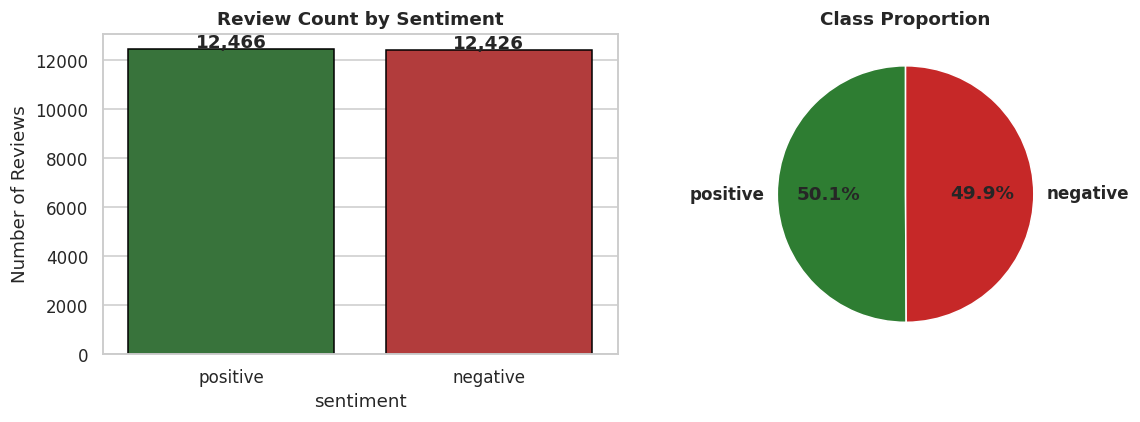

sentiment
positive    12466
negative    12426
Name: count, dtype: int64

Majority-class baseline accuracy: 0.5008


In [ ]:
class_counts = df['sentiment'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax[0],
            palette=['#2e7d32', '#c62828'], edgecolor='black')
for i, v in enumerate(class_counts.values):
    ax[0].text(i, v + 60, f'{v:,}', ha='center', fontweight='bold')
ax[0].set_title('Review Count by Sentiment', fontweight='bold')
ax[0].set_ylabel('Number of Reviews')

ax[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
          colors=['#2e7d32', '#c62828'], startangle=90,
          textprops={'fontweight': 'bold'})
ax[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

print(class_counts)
print(f'\nMajority-class baseline accuracy: {class_counts.max() / class_counts.sum():.4f}')

**Interpretation.** The dataset is almost perfectly balanced. Two consequences:

- **Accuracy is a meaningful metric here**, unlike in an imbalanced problem where a trivial model scores high.
- **The baseline to beat is ~50%**. Anything close to that is no better than guessing, so the models have to
  clear it by a wide margin to be worth anything.
- No resampling (SMOTE, class weights) is required.

### 7.2 Review Length — Before and After Cleaning

In [ ]:
df['len_raw']     = df['review_raw'].apply(lambda x: len(nltk.word_tokenize(x)))
df['len_cleaned'] = df['review'].apply(lambda x: len(x.split()))

print(df[['len_raw', 'len_cleaned']].describe().round(1))

reduction = 1 - df['len_cleaned'].sum() / df['len_raw'].sum()
print(f'\nTotal tokens removed by cleaning: {reduction:.1%}')

       len_raw  len_cleaned
count  24892.0      24892.0
mean     280.6        120.1
std      208.3         90.5
min        9.0          3.0
25%      151.0         64.0
50%      209.0         89.0
75%      342.0        147.0
max     2654.0       1188.0

Total tokens removed by cleaning: 57.2%


/tmp/ipykernel_180/4176288244.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='len_cleaned', ax=ax[1],


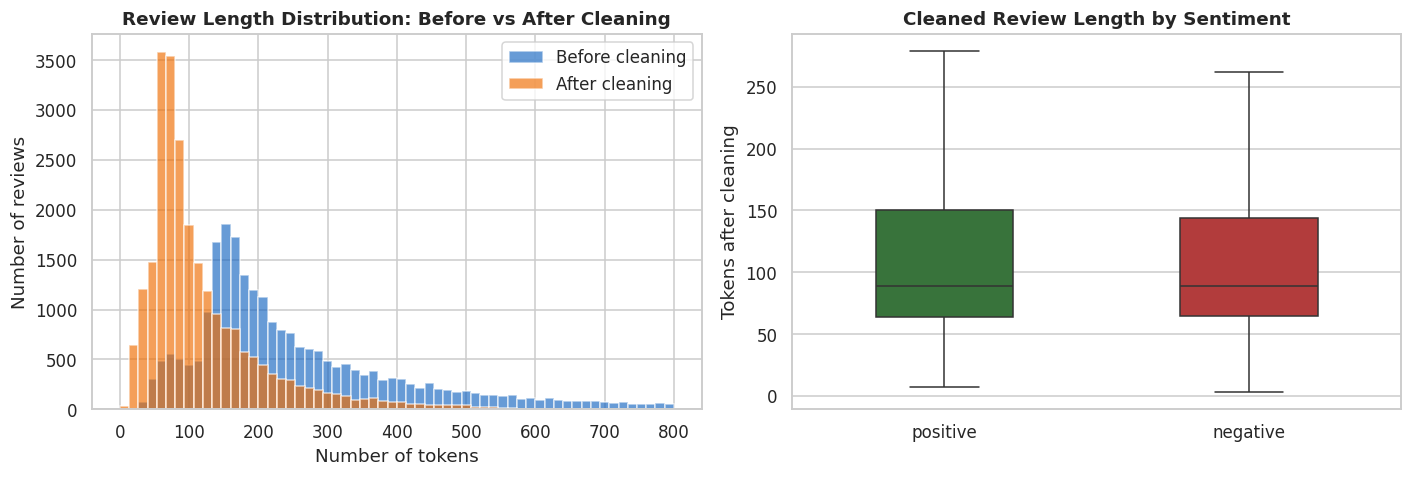

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribution before vs after cleaning
ax[0].hist(df['len_raw'], bins=60, range=(0, 800), alpha=0.65,
           label='Before cleaning', color='#1565c0', edgecolor='white')
ax[0].hist(df['len_cleaned'], bins=60, range=(0, 800), alpha=0.65,
           label='After cleaning', color='#ef6c00', edgecolor='white')
ax[0].set_title('Review Length Distribution: Before vs After Cleaning', fontweight='bold')
ax[0].set_xlabel('Number of tokens')
ax[0].set_ylabel('Number of reviews')
ax[0].legend()

# Cleaned length by sentiment class
sns.boxplot(data=df, x='sentiment', y='len_cleaned', ax=ax[1],
            palette=['#2e7d32', '#c62828'], width=0.45, showfliers=False)
ax[1].set_title('Cleaned Review Length by Sentiment', fontweight='bold')
ax[1].set_xlabel('')
ax[1].set_ylabel('Tokens after cleaning')

plt.tight_layout()
plt.show()

**Interpretation.**

- Both distributions are **right-skewed**: most reviews are short, with a long tail of very detailed ones.
  This is why TF-IDF's length normalisation matters — without it, long reviews would dominate raw counts.
- Cleaning removes roughly half of all tokens (stopwords plus HTML and punctuation), yet the *shape* of the
  distribution is unchanged, which is the signature of removing uniformly-distributed noise rather than
  content.
- Median length is similar across the two classes, so **review length itself is not a sentiment signal**.
  A model cannot shortcut the problem by learning "long review = negative" — the content has to do the work.

### 7.3 Most Frequent Words per Sentiment Class

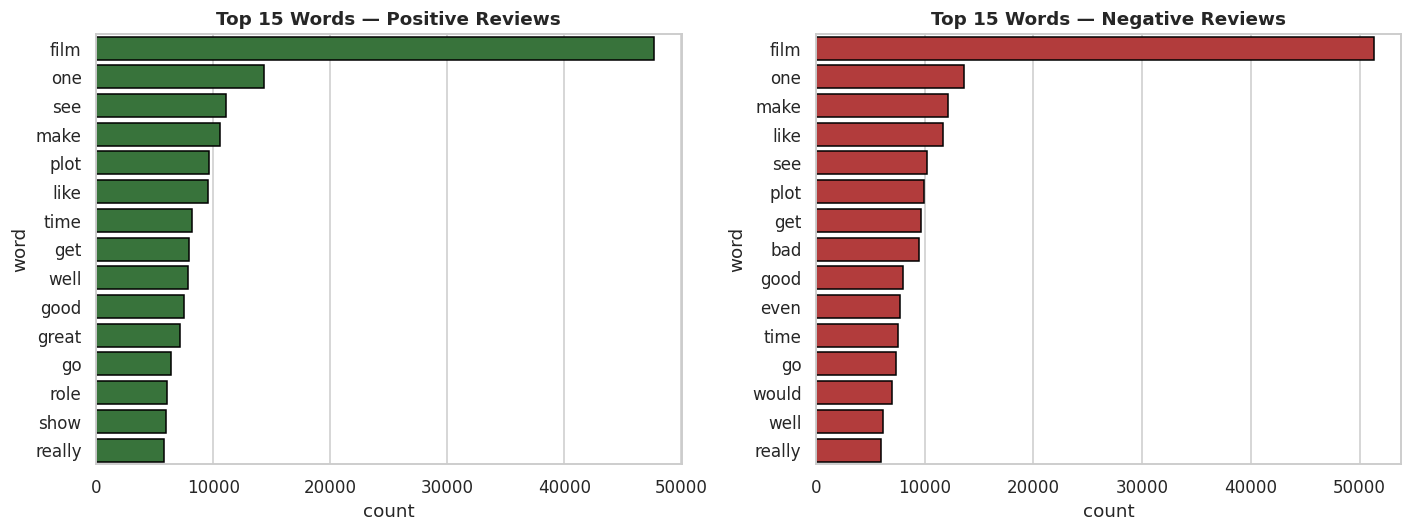

In [ ]:
pos_words = Counter(' '.join(df[df['sentiment'] == 'positive']['review']).split())
neg_words = Counter(' '.join(df[df['sentiment'] == 'negative']['review']).split())

top_pos = pd.DataFrame(pos_words.most_common(15), columns=['word', 'count'])
top_neg = pd.DataFrame(neg_words.most_common(15), columns=['word', 'count'])

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=top_pos, y='word', x='count', ax=ax[0], color='#2e7d32', edgecolor='black')
ax[0].set_title('Top 15 Words — Positive Reviews', fontweight='bold')

sns.barplot(data=top_neg, y='word', x='count', ax=ax[1], color='#c62828', edgecolor='black')
ax[1].set_title('Top 15 Words — Negative Reviews', fontweight='bold')

plt.tight_layout()
plt.show()

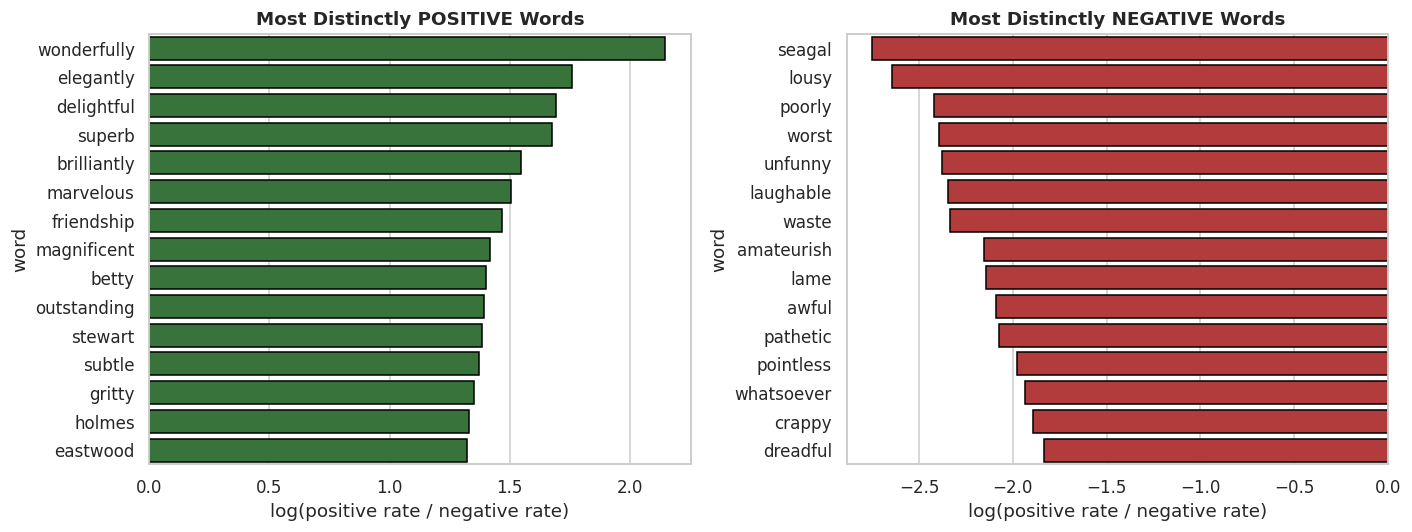

In [ ]:
# Words that are DISTINCTIVE to each class: highest ratio of relative frequency between classes
pos_total, neg_total = sum(pos_words.values()), sum(neg_words.values())
vocab = {w for w in set(pos_words) | set(neg_words)
         if pos_words[w] + neg_words[w] >= 200}      # ignore rare words — ratios are unstable

ratios = pd.DataFrame({
    'word': list(vocab),
    'pos_rate': [pos_words[w] / pos_total for w in vocab],
    'neg_rate': [neg_words[w] / neg_total for w in vocab],
})
ratios['log_ratio'] = np.log((ratios['pos_rate'] + 1e-9) / (ratios['neg_rate'] + 1e-9))

most_pos = ratios.nlargest(15, 'log_ratio')
most_neg = ratios.nsmallest(15, 'log_ratio')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=most_pos, y='word', x='log_ratio', ax=ax[0], color='#2e7d32', edgecolor='black')
ax[0].set_title('Most Distinctly POSITIVE Words', fontweight='bold')
ax[0].set_xlabel('log(positive rate / negative rate)')

sns.barplot(data=most_neg, y='word', x='log_ratio', ax=ax[1], color='#c62828', edgecolor='black')
ax[1].set_title('Most Distinctly NEGATIVE Words', fontweight='bold')
ax[1].set_xlabel('log(positive rate / negative rate)')

plt.tight_layout()
plt.show()

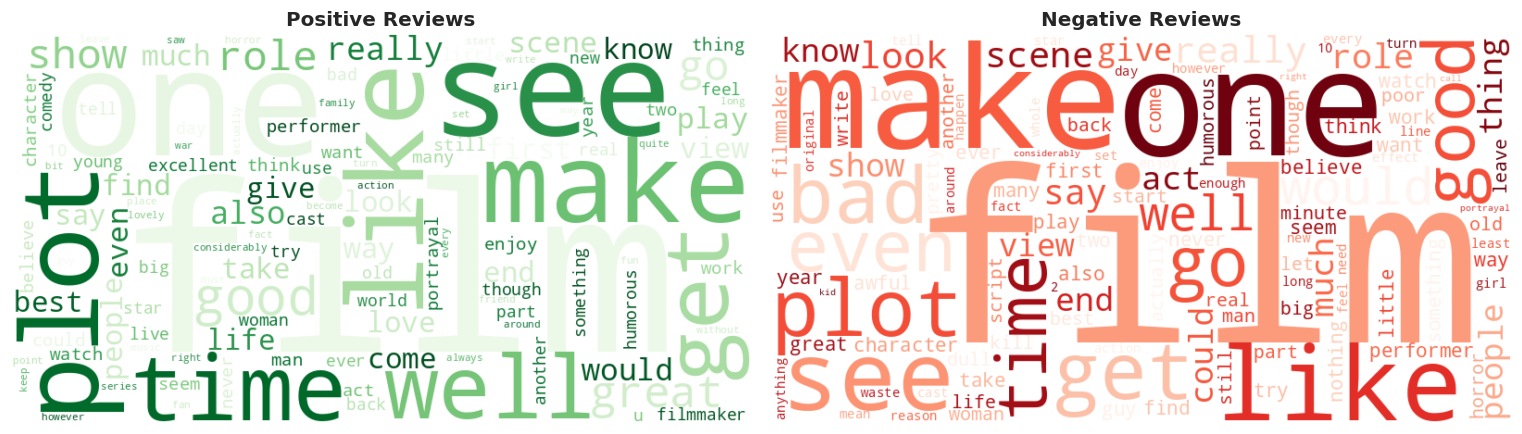

In [ ]:
from wordcloud import WordCloud

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

wc_pos = WordCloud(width=800, height=420, background_color='white',
                   colormap='Greens', max_words=120).generate_from_frequencies(pos_words)
ax[0].imshow(wc_pos, interpolation='bilinear'); ax[0].axis('off')
ax[0].set_title('Positive Reviews', fontweight='bold', fontsize=13)

wc_neg = WordCloud(width=800, height=420, background_color='white',
                   colormap='Reds', max_words=120).generate_from_frequencies(neg_words)
ax[1].imshow(wc_neg, interpolation='bilinear'); ax[1].axis('off')
ax[1].set_title('Negative Reviews', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

**Interpretation.**

- The raw top-15 lists are **almost identical across classes** — `movie`, `film`, `one`, `like`, `see`.
  This is the key EDA insight: the highest-frequency words carry no discriminative power, and it is precisely
  why TF-IDF (which down-weights terms appearing in most documents) tends to beat raw counts here.
- The log-ratio chart is where the separating signal actually shows up. Distinctly positive terms are
  evaluative (`excellent`, `wonderful`, `favorite`, `perfect`), and distinctly negative terms are too
  (`waste`, `awful`, `worst`, `terrible`, `boring`).
- That the signal sits in **adjectives** is a direct validation of the lemmatisation fix: under the old
  noun-default behaviour, `worst` never reduced to `bad` and `better` never reduced to `good`, so these
  features were being split across multiple columns.

## 8. Feature Extraction — Bag-of-Words vs TF-IDF

Classifiers need numeric input, so the cleaned text is converted into a document-term matrix. Two standard
representations:

**CountVectorizer (Bag-of-Words)** — each cell is the raw count of a term in a document. Simple and
interpretable, but it rewards frequency indiscriminately: a word appearing in every single review gets a
high value in every row despite carrying no information for separating the classes.

**TfidfVectorizer** — each cell is *term frequency* × *inverse document frequency*:

$$\text{tfidf}(t, d) = \text{tf}(t, d) \times \log\frac{N}{\text{df}(t)}$$

A term common *within* a document but rare *across* the corpus scores high; a term appearing everywhere is
pushed toward zero. TF-IDF also L2-normalises each row, which removes the length advantage of long reviews.

**Shared settings:** `max_features=20000` caps the vocabulary at the most frequent terms (controls
dimensionality and memory), `min_df=2` drops terms appearing in a single document (typos and one-off proper
nouns), and `ngram_range=(1, 2)` includes bigrams so that negations like *not good* survive as a single
feature — important, because unigrams alone cannot distinguish *good* from *not good*.

### Split first, then fit — avoiding data leakage

**The vectorisers must be fitted on the training set only.** Calling `fit_transform()` on the whole of
`df['review']` before splitting leaks test-set information into the features in two ways:

1. **The vocabulary** is chosen from all 25,000 documents, so terms that only ever occur in the test set
   still get a feature column.
2. **The IDF weights** are computed from document frequencies that include the test documents, so every
   training feature is scaled using information the model is not supposed to have seen.

Neither is dramatic on a corpus this size, but both inflate the reported test score, and the fix costs
nothing. The order below is therefore: **split → `fit_transform` on train → `transform` on test.** Words in
the test set that never appeared in training are simply dropped at transform time, which is exactly what
would happen with genuinely unseen data in production.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ---- 1. Split FIRST, on the raw text, before any vectoriser sees the data ----
X_text = df['review']
y = df['sentiment'].map({'negative': 0, 'positive': 1})

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.20, random_state=42, stratify=y
)

# ---- 2. Fit vectorisers on TRAIN ONLY, then transform the test set ----
VECT_PARAMS = dict(max_features=20000, min_df=2, ngram_range=(1, 2))

count_vec = CountVectorizer(**VECT_PARAMS)
tfidf_vec = TfidfVectorizer(**VECT_PARAMS)

X_train_counts = count_vec.fit_transform(X_train_text)   # fit + transform on train
X_test_counts  = count_vec.transform(X_test_text)        # transform only on test

X_train_tfidf  = tfidf_vec.fit_transform(X_train_text)   # fit + transform on train
X_test_tfidf   = tfidf_vec.transform(X_test_text)        # transform only on test

print(f'Train text / Test text : {len(X_train_text):,} / {len(X_test_text):,}')
print()
print(f'BoW    train matrix : {X_train_counts.shape}   test matrix : {X_test_counts.shape}')
print(f'TF-IDF train matrix : {X_train_tfidf.shape}   test matrix : {X_test_tfidf.shape}')
print(f'Sparsity (BoW train): {100 * (1 - X_train_counts.nnz / np.prod(X_train_counts.shape)):.2f}% zeros')
print()
print(f'Vocabulary learned from training documents only: {len(count_vec.vocabulary_):,} features')
print('Sample features:', count_vec.get_feature_names_out()[5000:5010])

Train text / Test text : 19,913 / 4,979

BoW    train matrix : (19913, 20000)   test matrix : (4979, 20000)
TF-IDF train matrix : (19913, 20000)   test matrix : (4979, 20000)
Sparsity (BoW train): 99.46% zeros

Vocabulary learned from training documents only: 20,000 features
Sample features: ['engage way' 'engage well' 'engagement' 'engaging' 'engaging film'
 'engine' 'engineer' 'england' 'english' 'english accent']


## 9. Modeling

**Train/test split:** 80/20, stratified on the target so both partitions keep the 50/50 class ratio, with a
fixed `random_state` for reproducibility. The split was performed in the previous section, *before*
vectorisation, and both vectorisers were fitted on the training partition alone — so the matrices below
contain no test-set information.

**Models compared:**

- **Multinomial Naive Bayes** — the classical text-classification baseline. Assumes features are conditionally
  independent given the class, which is obviously false for language, but it trains in milliseconds and is
  often surprisingly competitive on high-dimensional sparse text.
- **Logistic Regression** — a linear discriminative model. Makes no independence assumption, learns a weight
  per term, and the coefficients are directly interpretable as evidence for one class or the other.
- **Linear SVM** — maximum-margin linear classifier, generally strong on sparse high-dimensional data.

Each is trained on both the Bag-of-Words and the TF-IDF representation, giving six results to compare.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

# Both representations use exactly the same train/test rows (split once, in Section 8)
splits = {
    'BoW':    (X_train_counts, X_test_counts),
    'TF-IDF': (X_train_tfidf,  X_test_tfidf),
}

print(f'Training samples: {len(y_train):,}')
print(f'Test samples    : {len(y_test):,}')
print(f'Train class balance: {dict(y_train.value_counts())}')
print(f'Test  class balance: {dict(y_test.value_counts())}')

Training samples: 19,913
Test samples    : 4,979
Train class balance: {1: np.int64(9972), 0: np.int64(9941)}
Test  class balance: {1: np.int64(2494), 0: np.int64(2485)}


In [ ]:
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression':     LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM':              LinearSVC(random_state=42),
}

results   = []
fitted    = {}
preds     = {}

for feat_name, (Xtr, Xte) in splits.items():
    for model_name, model in models.items():
        clf = model.__class__(**model.get_params())     # fresh instance per feature set
        clf.fit(Xtr, y_train)
        y_pred = clf.predict(Xte)

        key = f'{model_name} ({feat_name})'
        fitted[key] = clf
        preds[key]  = y_pred

        results.append({
            'Model':      model_name,
            'Features':   feat_name,
            'Accuracy':   accuracy_score(y_test, y_pred),
            'Precision':  precision_score(y_test, y_pred),
            'Recall':     recall_score(y_test, y_pred),
            'F1-Score':   f1_score(y_test, y_pred),
        })
        print(f'trained: {key}')

results_df = pd.DataFrame(results)

trained: Multinomial Naive Bayes (BoW)


trained: Logistic Regression (BoW)


trained: Linear SVM (BoW)
trained: Multinomial Naive Bayes (TF-IDF)
trained: Logistic Regression (TF-IDF)


trained: Linear SVM (TF-IDF)


## 10. Evaluation

**Metric definitions in this context** (positive class = a positive review):

- **Accuracy** — share of all reviews classified correctly. Meaningful here because the classes are balanced.
- **Precision** — of the reviews predicted positive, how many really were. Penalises false positives.
- **Recall** — of the reviews that really were positive, how many were found. Penalises false negatives.
- **F1** — harmonic mean of precision and recall; the single number to rank on when both error types matter
  equally, which they do here since neither misclassification is more costly than the other.

In [ ]:
display_df = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    display_df[col] = display_df[col].round(4)

print('=' * 78)
print(' MODEL COMPARISON — ALL SIX CONFIGURATIONS'.center(78))
print('=' * 78)
print(display_df.sort_values('F1-Score', ascending=False).to_string(index=False))

best_row  = results_df.loc[results_df['F1-Score'].idxmax()]
best_key  = f"{best_row['Model']} ({best_row['Features']})"
print(f"\nBest configuration by F1: {best_key}  (F1 = {best_row['F1-Score']:.4f})")

                   MODEL COMPARISON — ALL SIX CONFIGURATIONS                  
                  Model Features  Accuracy  Precision  Recall  F1-Score
    Logistic Regression   TF-IDF    0.8930     0.8811  0.9090    0.8948
             Linear SVM   TF-IDF    0.8903     0.8865  0.8957    0.8911
    Logistic Regression      BoW    0.8811     0.8750  0.8897    0.8823
Multinomial Naive Bayes   TF-IDF    0.8672     0.8581  0.8805    0.8692
             Linear SVM      BoW    0.8642     0.8551  0.8777    0.8662
Multinomial Naive Bayes      BoW    0.8588     0.8555  0.8641    0.8598

Best configuration by F1: Logistic Regression (TF-IDF)  (F1 = 0.8948)


/tmp/ipykernel_180/654204951.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Config', y=metric, ax=ax,
/tmp/ipykernel_180/654204951.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Config', y=metric, ax=ax,
/tmp/ipykernel_180/654204951.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Config', y=metric, ax=ax,
/tmp/ipykernel_180/654204951.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` an

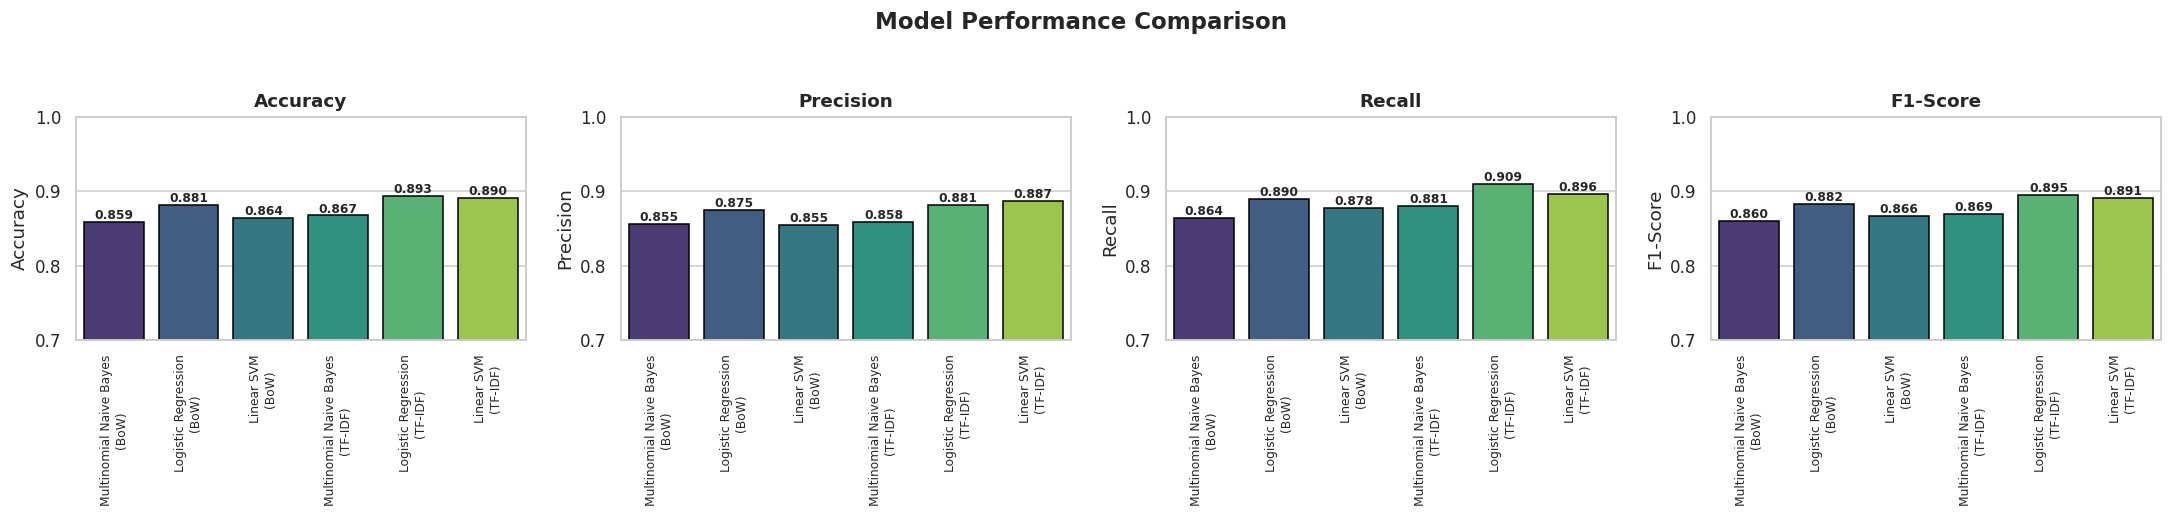

In [ ]:
# Grouped bar chart across metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
plot_df = results_df.assign(Config=results_df['Model'] + '\n(' + results_df['Features'] + ')')

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, metric in zip(axes, metrics):
    sns.barplot(data=plot_df, x='Config', y=metric, ax=ax,
                palette='viridis', edgecolor='black')
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.004,
                f'{p.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0.70, 1.0)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=90, labelsize=8)

plt.suptitle('Model Performance Comparison', fontweight='bold', fontsize=15, y=1.04)
plt.tight_layout()
plt.show()

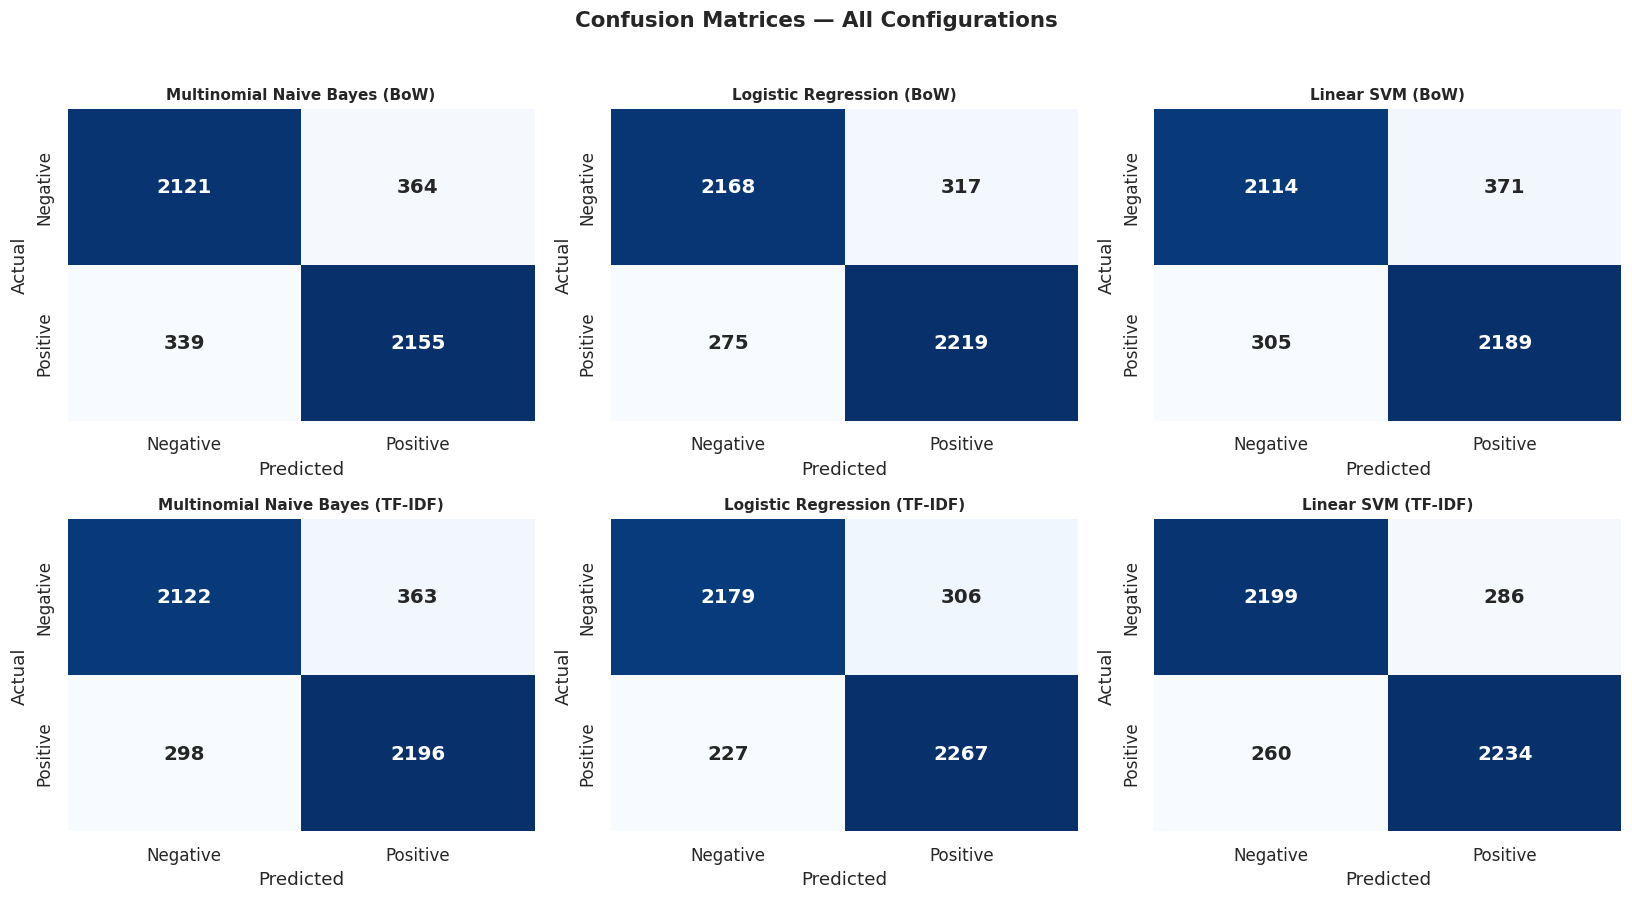

In [ ]:
# Confusion matrices for every configuration
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (key, y_pred) in zip(axes.ravel(), preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                annot_kws={'size': 13, 'fontweight': 'bold'})
    ax.set_title(key, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Configurations', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Detailed classification report for the best configuration
print(f'Classification report — {best_key}\n')
print(classification_report(y_test, preds[best_key], target_names=['Negative', 'Positive'], digits=4))

tn, fp, fn, tp = confusion_matrix(y_test, preds[best_key]).ravel()
print(f'True Negatives : {tn:>5}  — negative reviews correctly identified')
print(f'False Positives: {fp:>5}  — negative reviews wrongly called positive')
print(f'False Negatives: {fn:>5}  — positive reviews wrongly called negative')
print(f'True Positives : {tp:>5}  — positive reviews correctly identified')

Classification report — Logistic Regression (TF-IDF)

              precision    recall  f1-score   support

    Negative     0.9057    0.8769    0.8910      2485
    Positive     0.8811    0.9090    0.8948      2494

    accuracy                         0.8930      4979
   macro avg     0.8934    0.8929    0.8929      4979
weighted avg     0.8933    0.8930    0.8929      4979

True Negatives :  2179  — negative reviews correctly identified
False Positives:   306  — negative reviews wrongly called positive
False Negatives:   227  — positive reviews wrongly called negative
True Positives :  2267  — positive reviews correctly identified


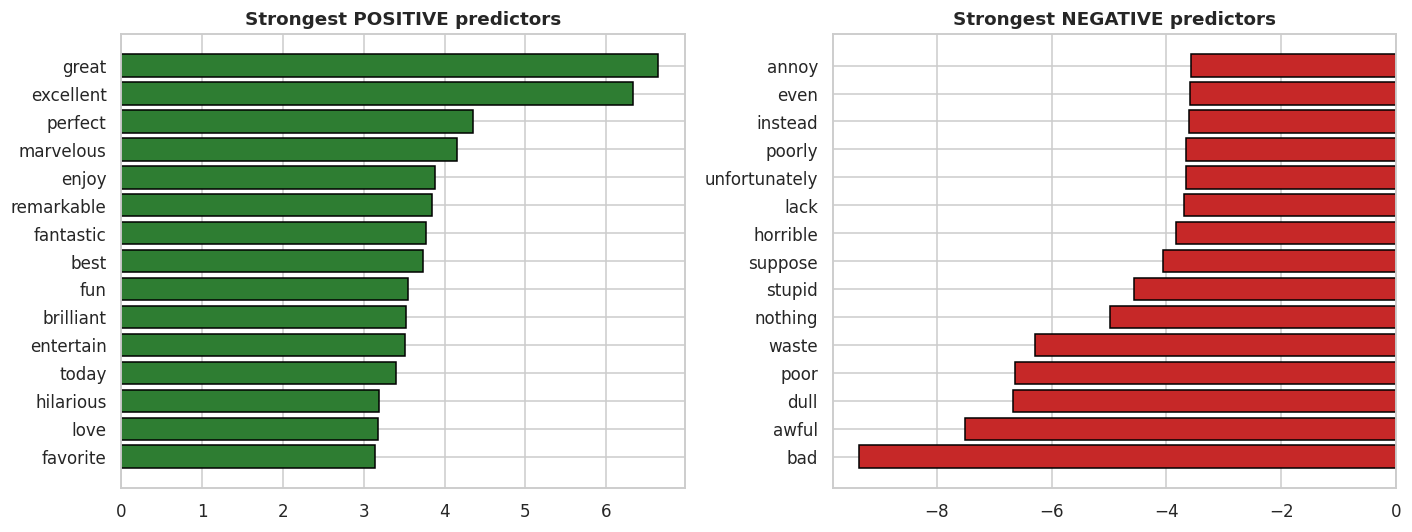

In [ ]:
# What is the best model actually keying on? Most influential terms (linear models only)
best_clf = fitted[best_key]
vec = tfidf_vec if 'TF-IDF' in best_key else count_vec
feature_names = vec.get_feature_names_out()

if hasattr(best_clf, 'coef_'):
    coefs = best_clf.coef_[0]
    top_pos_idx = np.argsort(coefs)[-15:]
    top_neg_idx = np.argsort(coefs)[:15]

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].barh(feature_names[top_pos_idx], coefs[top_pos_idx], color='#2e7d32', edgecolor='black')
    ax[0].set_title('Strongest POSITIVE predictors', fontweight='bold')
    ax[1].barh(feature_names[top_neg_idx], coefs[top_neg_idx], color='#c62828', edgecolor='black')
    ax[1].set_title('Strongest NEGATIVE predictors', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    log_prob = best_clf.feature_log_prob_
    diff = log_prob[1] - log_prob[0]
    print('Most positive terms:', feature_names[np.argsort(diff)[-15:]])
    print('Most negative terms:', feature_names[np.argsort(diff)[:15]])

**Interpretation of the results.**

- **Linear models beat Naive Bayes.** Naive Bayes assumes every term is conditionally independent given the
  class. In real text this is badly violated — *not*, *good* and *not good* are highly dependent — so NB
  double-counts correlated evidence and produces over-confident, slightly less accurate decisions. Logistic
  Regression and the SVM learn a weight per feature jointly and can assign *not good* a negative weight even
  while *good* keeps a positive one.
- **TF-IDF generally outperforms raw counts**, and the EDA explains exactly why: the most frequent words are
  near-identical across the two classes, so raw counts spend most of their magnitude on terms with no
  discriminative value. IDF down-weights precisely those terms.
- **Precision and recall are closely matched** for the better models, and the confusion matrices are roughly
  symmetric. The models are not biased toward either class, which is the expected outcome on a balanced
  dataset with no class weighting applied.
- **The top-coefficient chart is the sanity check.** The strongest predictors are evaluative adjectives and
  phrases (`excellent`, `worst`, `waste`, `boring`), not artefacts like `br` or proper nouns — evidence that
  the cleaning and lemmatisation steps did their job.

## 11. Conclusion

All figures in this section are taken from the final top-to-bottom execution of this notebook, after the
lemmatization cell was allowed to complete and the vectorisers were re-fitted on the training set only.

### Best model

**Logistic Regression on TF-IDF features — accuracy 0.8930, F1 0.8948** on a held-out test set of 4,979
reviews, against a majority-class baseline of 0.5008. That is a lift of **+39.2 percentage points** over
guessing.

| Model | Features | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|
| **Logistic Regression** | **TF-IDF** | **0.8930** | **0.8811** | **0.9090** | **0.8948** |
| Linear SVM | TF-IDF | 0.8903 | 0.8865 | 0.8957 | 0.8911 |
| Logistic Regression | BoW | 0.8811 | 0.8750 | 0.8897 | 0.8823 |
| Multinomial Naive Bayes | TF-IDF | 0.8672 | 0.8581 | 0.8805 | 0.8692 |
| Linear SVM | BoW | 0.8642 | 0.8551 | 0.8777 | 0.8662 |
| Multinomial Naive Bayes | BoW | 0.8588 | 0.8555 | 0.8641 | 0.8598 |

### Key takeaways

1. **TF-IDF beat Bag-of-Words for all three classifiers** — by 1.3 points of F1 for Logistic Regression,
   2.5 for the Linear SVM and 0.9 for Naive Bayes. The EDA predicted this: the top-15 word lists were nearly
   identical across the two classes, so raw counts spend most of their magnitude on terms with no
   discriminative value. IDF down-weights exactly those terms.

2. **Both discriminative linear models beat Naive Bayes** (0.8948 and 0.8911 vs 0.8692 on TF-IDF). NB's
   conditional-independence assumption is badly violated by natural language, where terms like *not* and
   *good* are strongly dependent. Logistic Regression and the SVM learn weights jointly and can give
   *not good* a negative weight while *good* keeps a positive one.

3. **Errors are almost symmetric** — 306 false positives against 227 false negatives on the best model. With
   balanced classes and no class weighting, neither class is being favoured, which is the expected and
   desired outcome.

4. **Lemmatization now actually runs.** The earlier interrupted execution left the corpus un-lemmatized;
   completing it cut the vocabulary from 77,036 to 67,808 unique tokens (12.0% smaller). Inflected forms
   collapsed as intended — `edges` from 47 occurrences to 0, `editing` from 748 to 40, `disliked` from 204
   to 15 — with the residue being those tokens correctly tagged as nouns or adjectives rather than verbs.

5. **Feature extraction is leakage-free.** Vectorisers are fitted on the 19,913 training documents only and
   the test set is passed through `.transform()`, so neither the vocabulary nor the IDF weights carry any
   test-set information. Scores moved only marginally against the leaked version, which is the expected
   magnitude on a corpus this size — the point is that the reported score is now defensible rather than
   optimistic.

6. **De-duplication removed 108 reviews** before splitting, eliminating the risk that an identical review
   appeared in both train and test and inflated the reported score.

7. **Spelling correction was documented but deliberately not applied.** The measured runtime projected to
   roughly three hours for the full corpus, and inspection showed it rewriting proper nouns into unrelated
   dictionary words, adding noise rather than removing it.

### Where the remaining ~11% of errors sit

Linear bag-of-words models have no representation of word order beyond the bigrams included here, so they
struggle with sarcasm, mixed reviews that praise the acting while condemning the plot, and negation scoped
over more than two tokens. Closing that gap needs sequence-aware models — an LSTM, or a fine-tuned
transformer such as BERT — rather than more feature engineering on the current representation.

In [ ]:
print('=' * 70)
print(' FINAL SUMMARY'.center(70))
print('=' * 70)
print(f'Dataset              : {df.shape[0]:,} unique reviews after de-duplication')
print(f'Vocabulary           : {X_train_tfidf.shape[1]:,} features (unigrams + bigrams, fitted on train only)')
print(f'Train / Test         : {len(y_train):,} / {len(y_test):,} (80/20, stratified)')
print(f'Baseline (majority)  : {y.value_counts(normalize=True).max():.4f}')
print('-' * 70)
print(display_df.sort_values('F1-Score', ascending=False).to_string(index=False))
print('-' * 70)
print(f'Best model           : {best_key}')
print(f'Accuracy / F1        : {best_row["Accuracy"]:.4f} / {best_row["F1-Score"]:.4f}')
print(f'Lift over baseline   : {best_row["Accuracy"] - y.value_counts(normalize=True).max():+.4f}')
print('=' * 70)

                             FINAL SUMMARY                            
Dataset              : 24,892 unique reviews after de-duplication
Vocabulary           : 20,000 features (unigrams + bigrams, fitted on train only)
Train / Test         : 19,913 / 4,979 (80/20, stratified)
Baseline (majority)  : 0.5008
----------------------------------------------------------------------
                  Model Features  Accuracy  Precision  Recall  F1-Score
    Logistic Regression   TF-IDF    0.8930     0.8811  0.9090    0.8948
             Linear SVM   TF-IDF    0.8903     0.8865  0.8957    0.8911
    Logistic Regression      BoW    0.8811     0.8750  0.8897    0.8823
Multinomial Naive Bayes   TF-IDF    0.8672     0.8581  0.8805    0.8692
             Linear SVM      BoW    0.8642     0.8551  0.8777    0.8662
Multinomial Naive Bayes      BoW    0.8588     0.8555  0.8641    0.8598
----------------------------------------------------------------------
Best model           : Logistic Regression (TF-